In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

df['target'] = iris.target

print("İşte senin veri setin:")
print(df.head())

İşte senin veri setin:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


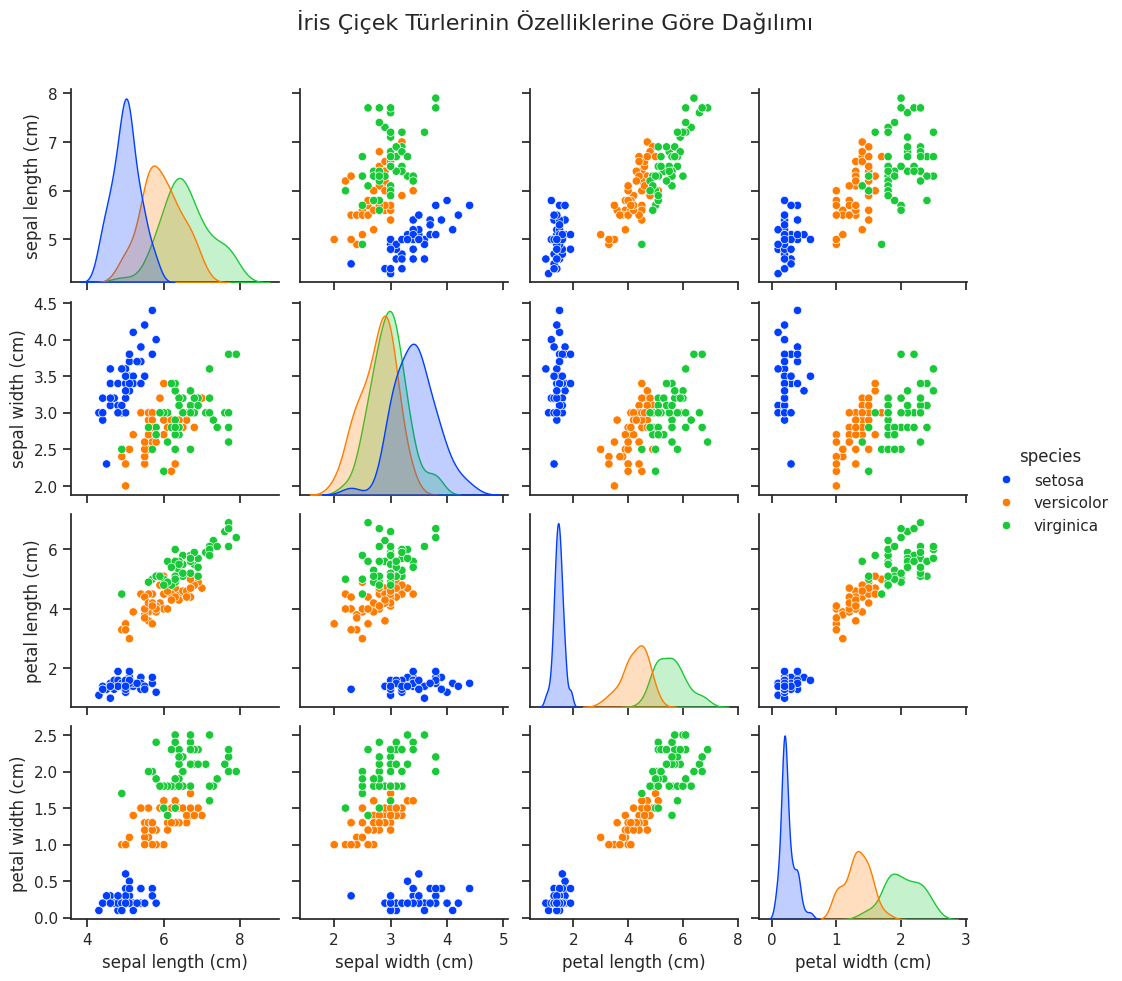

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks")

df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

g = sns.pairplot(df.drop('target', axis=1), hue='species', palette='bright')


plt.subplots_adjust(top=0.9)
g.fig.suptitle('İris Çiçek Türlerinin Özelliklerine Göre Dağılımı', fontsize=16)

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['target', 'species'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim için ayrılan örnek sayısı:", len(X_train))
print("Test (Sınav) için ayrılan örnek sayısı:", len(X_test))


Eğitim için ayrılan örnek sayısı: 120
Test (Sınav) için ayrılan örnek sayısı: 30


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")

Model başarıyla eğitildi!


In [ ]:

tahminler = model.predict(X_test)

from sklearn.metrics import accuracy_score

basari = accuracy_score(y_test, tahminler)
print(f"Modelin Başarı Oranı: %{basari * 100}")

Modelin Başarı Oranı: %100.0


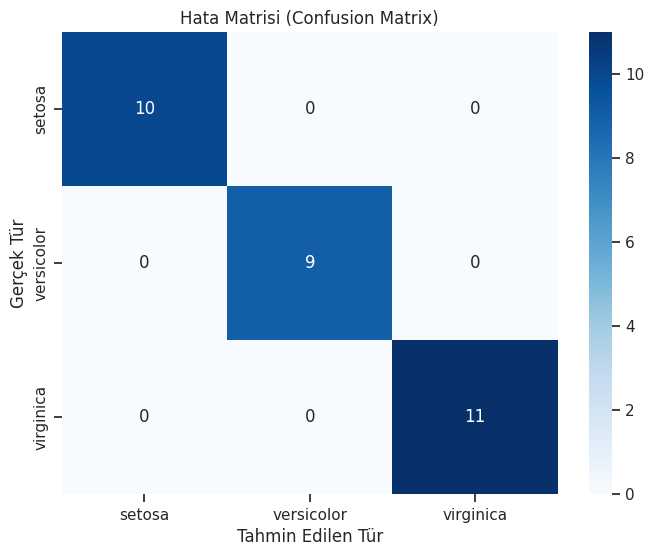

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, tahminler)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel('Tahmin Edilen Tür')
plt.ylabel('Gerçek Tür')
plt.title('Hata Matrisi (Confusion Matrix)')
plt.show()